In [52]:
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd


In [54]:

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

INPUT_LIST = Path("input_list.txt")

# ------------------------------------------------------------------
# Read selected waveform information
# ------------------------------------------------------------------

selected = pd.read_csv("waveforms_run_039510_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.csv")

selected = selected.filter(items={"event", "channel", "dt_ns_coinc", "dt_ns_save"})


In [55]:

dt_ns_coinc = np.array(selected["dt_ns_coinc"])/16
dt_ns_save = np.array(selected["dt_ns_save"])/16

print(dt_ns_coinc[dt_ns_coinc==0].size)

30063


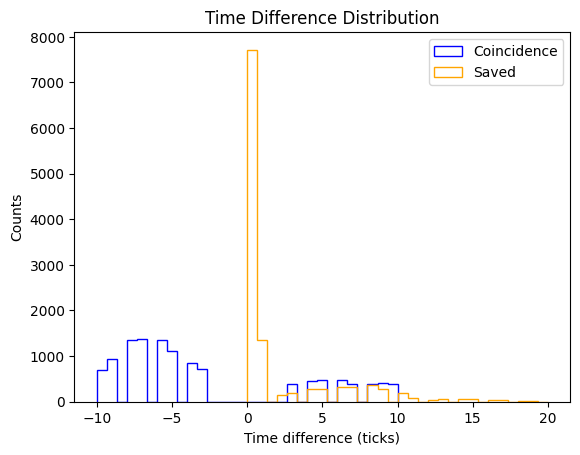

In [63]:
plt.figure()
plt.hist(dt_ns_coinc[abs(dt_ns_coinc)>2], bins=30, histtype="step", color="blue", label="Coincidence")
plt.hist(abs(dt_ns_save[abs(dt_ns_coinc)>2]), bins=30, histtype="step", color="orange", label="Saved")
plt.xlabel("Time difference (ticks)")
plt.ylabel("Counts")
plt.title("Time Difference Distribution")
plt.legend()
plt.show()
